In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import os

2026-04-03 17:43:10.094696: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775238190.118035     397 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775238190.125451     397 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775238190.144052     397 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775238190.144081     397 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775238190.144083     397 computation_placer.cc:177] computation placer alr

In [2]:
print(f"TensorFlow Version: {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

TensorFlow Version: 2.19.0
Num GPUs Available:  1


In [3]:
NEW_DATA_DIR = '/kaggle/working/xpathology_5_classes'
os.makedirs(NEW_DATA_DIR, exist_ok=True)

# The exact paths to the 5 actual class folders in the Kaggle input
source_dirs = [
    '/kaggle/input/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets/colon_aca',
    '/kaggle/input/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets/colon_n',
    '/kaggle/input/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_aca',
    '/kaggle/input/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_n',
    '/kaggle/input/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/lung_image_sets/lung_scc'
]

# symlinks so Keras sees all 5 classes cleanly
for src in source_dirs:
    folder_name = os.path.basename(src)
    dest = os.path.join(NEW_DATA_DIR, folder_name)
    if not os.path.exists(dest):
        os.symlink(src, dest)
        
print(f"Symlinks created successfully. Target directory: {NEW_DATA_DIR}")

Symlinks created successfully. Target directory: /kaggle/working/xpathology_5_classes


In [4]:
# laoding the dataset

IMG_SIZE = (224, 224)
BATCH_SIZE = 64

# Load Training Data
train_ds = tf.keras.utils.image_dataset_from_directory(
    NEW_DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Load Validation Data
val_ds = tf.keras.utils.image_dataset_from_directory(
    NEW_DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
print(f"Detected Classes: {class_names}")

Found 25000 files belonging to 5 classes.
Using 20000 files for training.


I0000 00:00:1775238212.197537     397 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 25000 files belonging to 5 classes.
Using 5000 files for validation.
Detected Classes: ['colon_aca', 'colon_n', 'lung_aca', 'lung_n', 'lung_scc']


In [5]:
# CPU/GPU Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [6]:
# Building Architecture

inputs = layers.Input(shape=(224, 224, 3), name="microscope_image_input")

# Data Augmentation
x = layers.RandomFlip("horizontal_and_vertical")(inputs)
x = layers.RandomRotation(0.3)(x)
x = layers.RandomZoom(0.2)(x)
x = layers.RandomContrast(0.2)(x)

# Preprocessing specifically for MobileNetV2
x = layers.Lambda(tf.keras.applications.mobilenet_v2.preprocess_input)(x)

# The Backbone
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Freeze base weights initially
x = base_model(x, training=False) 

# The Classification Head
x = layers.GlobalAveragePooling2D(name="spatial_pooling")(x)
x = layers.Dropout(0.5, name="uncertainty_dropout")(x)

# Final Layer: 5 nodes, Softmax activation
outputs = layers.Dense(5, activation='softmax', name="multi_class_predictions")(x)

# Build & Compile Model
model = models.Model(inputs=inputs, outputs=outputs, name="XPathology_V2_MultiClass")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # The overconfidence fix
    metrics=['accuracy']
)

model.summary()

Model: "XPathology_V2_MultiClass"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ microscope_image_input          │ (None, 224, 224, 3)    │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_pooling                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ uncertainty_dropout (Dropout)   │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multi_class_predictions (Dense) │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# Training

# Callbacks
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
checkpoint = callbacks.ModelCheckpoint(
    '/kaggle/working/xpathology_v2_5class.keras', monitor='val_loss', save_best_only=True, verbose=1
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25, 
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

Epoch 1/25


I0000 00:00:1775238310.833778     465 cuda_dnn.cc:529] Loaded cuDNN version 91002


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7257 - loss: 1.0387
Epoch 1: val_loss improved from inf to 0.53549, saving model to /kaggle/working/xpathology_v2_5class.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 108s 121ms/step - accuracy: 0.7261 - loss: 1.0379 - val_accuracy: 0.9608 - val_loss: 0.5355 - learning_rate: 0.0010
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9258 - loss: 0.6042
Epoch 2: val_loss improved from 0.53549 to 0.52977, saving model to /kaggle/working/xpathology_v2_5class.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.9258 - loss: 0.6042 - val_accuracy: 0.9608 - val_loss: 0.5298 - learning_rate: 0.0010
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9406 - loss: 0.5644
Epoch 3: val_loss improved from 0.52977 to 0.51128, saving model to /kaggle/working/xpathology_v2_5class.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 27s 87ms/step - accuracy: 0.9406 - loss: 0.5644 - val_accuracy: 0.9670 - val_loss: 0.5113 - learning_rat

In [8]:
# Fine-Tuning

# Unfreezing the base model
base_model.trainable = True

# unfreeze the top layers
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with a microscopic learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Train the top layers
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10, 
    callbacks=[
        callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        callbacks.ModelCheckpoint('/kaggle/working/xpathology_v2_5class_finetuned.keras', save_best_only=True)
    ]
)

print("\n🚀 Training Complete!")

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 133ms/step - accuracy: 0.7688 - loss: 0.9214 - val_accuracy: 0.8890 - val_loss: 0.7426
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.9236 - loss: 0.6070 - val_accuracy: 0.9262 - val_loss: 0.6947
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.9413 - loss: 0.5633 - val_accuracy: 0.9448 - val_loss: 0.6598
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.9578 - loss: 0.5344 - val_accuracy: 0.9592 - val_loss: 0.6119
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 126ms/step - accuracy: 0.9671 - loss: 0.5140 - val_accuracy: 0.9688 - val_loss: 0.5756
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.9688 - loss: 0.5065 - val_accuracy: 0.9782 - val_loss: 0.5363
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.9744 - loss: 0.4922 - val_accuracy: 0.9828 - val_loss: 0.5120
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 127ms/step - accuracy: 0.9767 - loss: 0

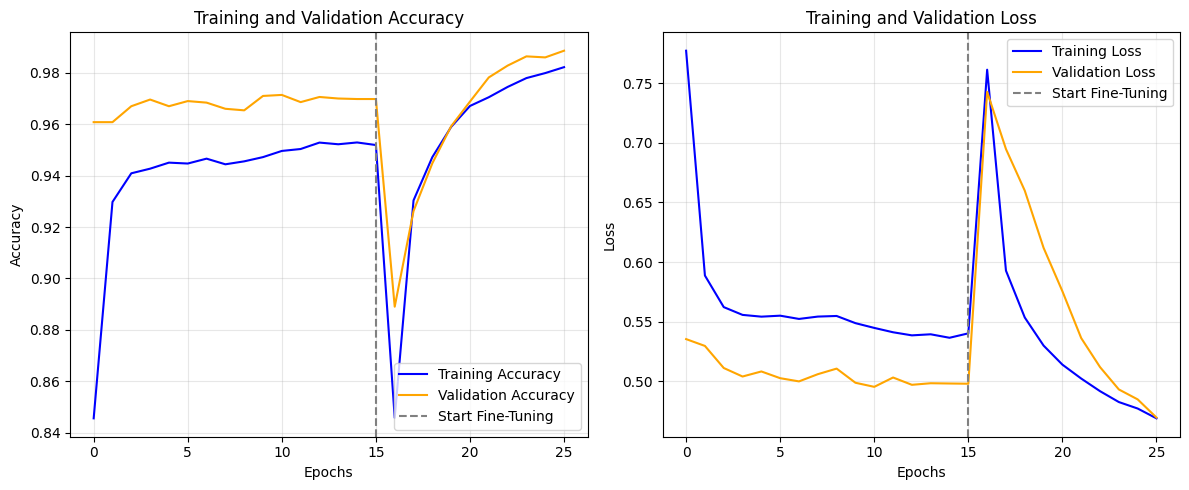

In [9]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Fine-Tuning Data
fine_acc = history_fine.history['accuracy']
fine_val_acc = history_fine.history['val_accuracy']
fine_loss = history_fine.history['loss']
fine_val_loss = history_fine.history['val_loss']

total_acc = acc + fine_acc
total_val_acc = val_acc + fine_val_acc
total_loss = loss + fine_loss
total_val_loss = val_loss + fine_val_loss

initial_epochs = len(acc)

# Plotting Accuracy
plt.figure(figsize=(12, 5))

# Subplot 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(total_acc, label='Training Accuracy', color='blue')
plt.plot(total_val_acc, label='Validation Accuracy', color='orange')
plt.axvline(x=initial_epochs-1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Subplot 2: Loss
plt.subplot(1, 2, 2)
plt.plot(total_loss, label='Training Loss', color='blue')
plt.plot(total_val_loss, label='Validation Loss', color='orange')
plt.axvline(x=initial_epochs-1, color='gray', linestyle='--', label='Start Fine-Tuning')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()